# 1. post performance clustring 

## Goal : Group posts into natural performance types.

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df = pd.read_csv('C:\\Users\\hanib\\data_mining -project\\marketing\\data\\sample_synthetic_posts.csv')
cols = [
    "followers_count",
    "likes_count",
    "comments_count",
    "views_count"
]
df_small = df[cols].copy()
df_small.head()

,followers_count,likes_count,comments_count,views_count
0,10435,219,8,0.0
1,1688,68,7,1577.0
2,14649,406,31,0.0
3,6223,217,24,0.0
4,8072,307,24,6080.0


In [131]:
df_small.describe()

,followers_count,likes_count,comments_count,views_count
count,300.000000,300.000000,300.000000,270.000000
mean,6613.820000,199.756667,15.603333,3696.355556
std,4365.635632,153.889389,13.094945,6467.478417
min,753.000000,11.000000,0.000000,0.000000
25%,2924.000000,85.000000,6.000000,0.000000
50%,5527.000000,144.000000,11.000000,0.000000
75%,10814.000000,288.250000,21.000000,4922.750000
max,18359.000000,888.000000,69.000000,37240.000000


In [132]:
df_small.isnull().sum()

followers_count     0
likes_count         0
comments_count      0
views_count        30
dtype: int64

In [133]:
df_small["views_count"] = pd.to_numeric(df_small["views_count"], errors="coerce")
df_small["views_count"] = df_small["views_count"].fillna(0)
df_small["views_count"] = df_small["views_count"].clip(lower=0)
df_small.isnull().sum()

followers_count    0
likes_count        0
comments_count     0
views_count        0
dtype: int64

In [134]:
df_small.duplicated().sum()

np.int64(0)

In [135]:

df_small['engagement'] = df_small['likes_count'] + df_small['comments_count']

df_small['engagement_rate'] = np.where(
    df_small['followers_count'] > 0,
      df_small['engagement'] / df_small['followers_count'],
        0
    )
df_small['comment_rate'] = np.where(
    df_small['followers_count'] > 0,
      df_small['comments_count'] / df_small['followers_count'],
        0
    )   
df_small['view_rate'] = np.where(
    df_small['followers_count'] > 0,
      df_small['views_count'] / df_small['followers_count'],
        0
    )
df_small['view_engagement_rate'] = np.where(
    df_small['views_count'] > 0,
      df_small['engagement'] / df_small['views_count'],
        0
    )
df_small['comments_to_likes_ratio'] = np.where(
    df_small['likes_count'] > 0,
      df_small['comments_count'] / df_small['likes_count'],
        0
    )

In [136]:
df_small.head()

,followers_count,likes_count,comments_count,views_count,engagement,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,10435,219,8,0.0,227,0.021754,0.000767,0.000000,0.000000,0.036530
1,1688,68,7,1577.0,75,0.044431,0.004147,0.934242,0.047559,0.102941
2,14649,406,31,0.0,437,0.029831,0.002116,0.000000,0.000000,0.076355
3,6223,217,24,0.0,241,0.038727,0.003857,0.000000,0.000000,0.110599
4,8072,307,24,6080.0,331,0.041006,0.002973,0.753221,0.054441,0.078176


In [137]:
df_small.columns

Index(['followers_count', 'likes_count', 'comments_count', 'views_count',
       'engagement', 'engagement_rate', 'comment_rate', 'view_rate',
       'view_engagement_rate', 'comments_to_likes_ratio'],
      dtype='object')

In [138]:
scale = StandardScaler()

features_to_scale = [
    "followers_count",
    "likes_count",
    "comments_count",
    "views_count",
    "engagement",
    "engagement_rate",
    "comment_rate",
    "view_rate",
    "view_engagement_rate",
    "comments_to_likes_ratio"
]
X_scaled = scale.fit_transform(df_small[features_to_scale])
df_scaled = pd.DataFrame(X_scaled, columns=features_to_scale)

df_scaled


,followers_count,likes_count,comments_count,views_count,engagement,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,0.876749,0.125255,-0.581601,-0.534516,0.070335,-1.182776,-1.485007,-0.663941,-0.478896,-1.432572
1,-1.130202,-0.857608,-0.658094,-0.281134,-0.848127,1.391136,1.674532,0.523707,1.027226,0.804302
2,1.843627,1.342444,1.177736,-0.534516,1.339262,-0.265957,-0.223596,-0.663941,-0.478896,-0.091185
3,-0.089671,0.112237,0.642286,-0.534516,0.154930,0.743733,1.403227,-0.663941,-0.478896,1.062236
4,0.334571,0.698050,0.642286,0.442379,0.698756,1.002360,0.577494,0.293586,1.245174,-0.029843
...,...,...,...,...,...,...,...,...,...,...
295,0.963708,1.108119,0.948257,-0.534516,1.103604,0.525453,0.218564,-0.663941,-0.478896,-0.114055
296,0.644551,-0.043979,-0.046151,0.635669,-0.044473,-1.146463,-0.713693,0.318597,0.425552,-0.045191
297,-0.249365,-0.590738,-0.505108,0.900459,-0.588299,-1.228627,-0.679558,1.390242,-0.060476,0.118119
298,-1.344733,-1.176551,-1.193545,-0.534516,-1.186507,-0.787943,-2.201596,-0.663941,-0.478896,-2.662965


In [139]:
df_kmeans = df_scaled.copy()

In [140]:
features = [
    "engagement_rate",
    "comment_rate",
    "view_rate",
    "view_engagement_rate",
    "comments_to_likes_ratio"
]


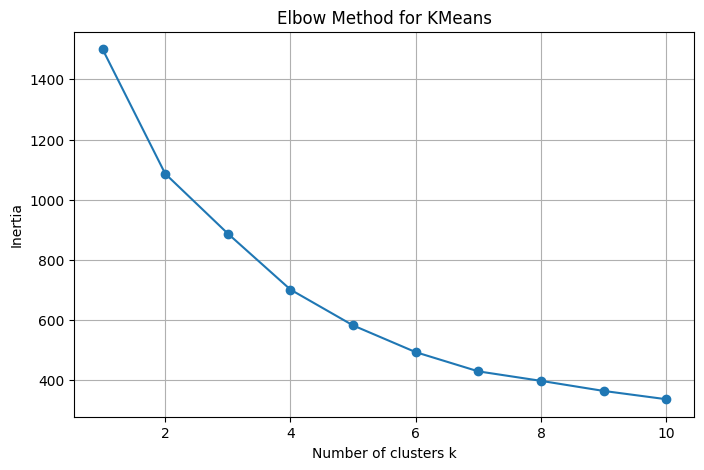

In [141]:
inertias = []
# Elbow method to find the optimal number of clusters

X = df_small[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.grid(True)
plt.show()

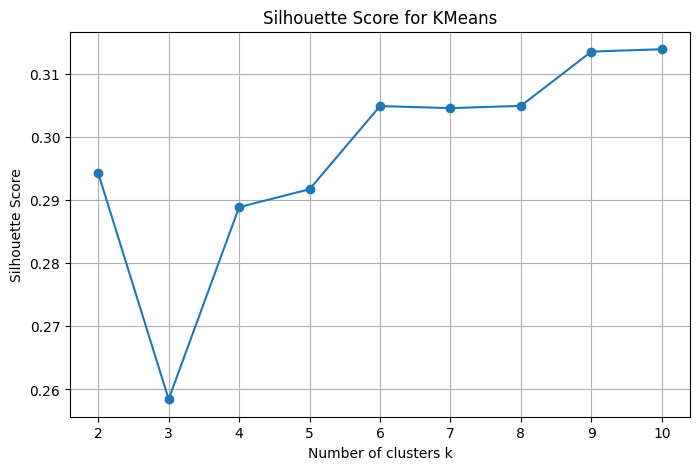

In [142]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for KMeans")
plt.grid(True)
plt.show()

In [143]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("number of iterations:", kmeans.n_iter_)


number of iterations: 7


In [144]:
# Assign cluster label to each row
df_small['cluster'] = kmeans_labels
df_small[['cluster'] + features].head()


,cluster,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,4,0.021754,0.000767,0.000000,0.000000,0.036530
1,1,0.044431,0.004147,0.934242,0.047559,0.102941
2,0,0.029831,0.002116,0.000000,0.000000,0.076355
3,2,0.038727,0.003857,0.000000,0.000000,0.110599
4,1,0.041006,0.002973,0.753221,0.054441,0.078176


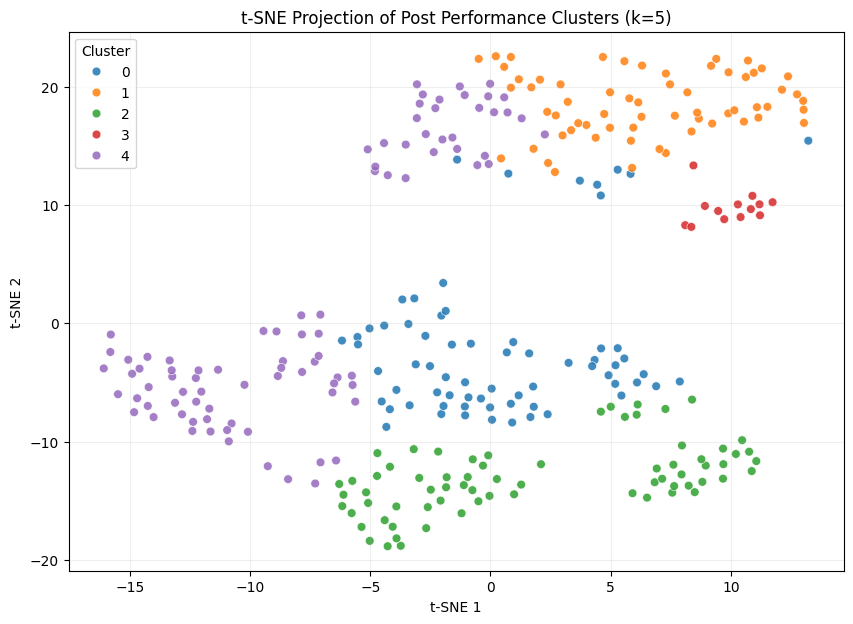

In [145]:
from sklearn.manifold import TSNE
import seaborn as sns

# t-SNE on the same scaled clustering features
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['cluster'] = df_small['cluster'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='cluster', palette='tab10', s=40, alpha=0.85)
plt.title('t-SNE Projection of Post Performance Clusters (k=5)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.2)
plt.show()


In [146]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN on the same scaled clustering features
dbscan = DBSCAN(eps=0.8, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_small['dbscan_cluster'] = dbscan_labels
df_small['dbscan_cluster'].value_counts().sort_index()


dbscan_cluster
-1    104
 0    175
 1     11
 2     10
Name: count, dtype: int64

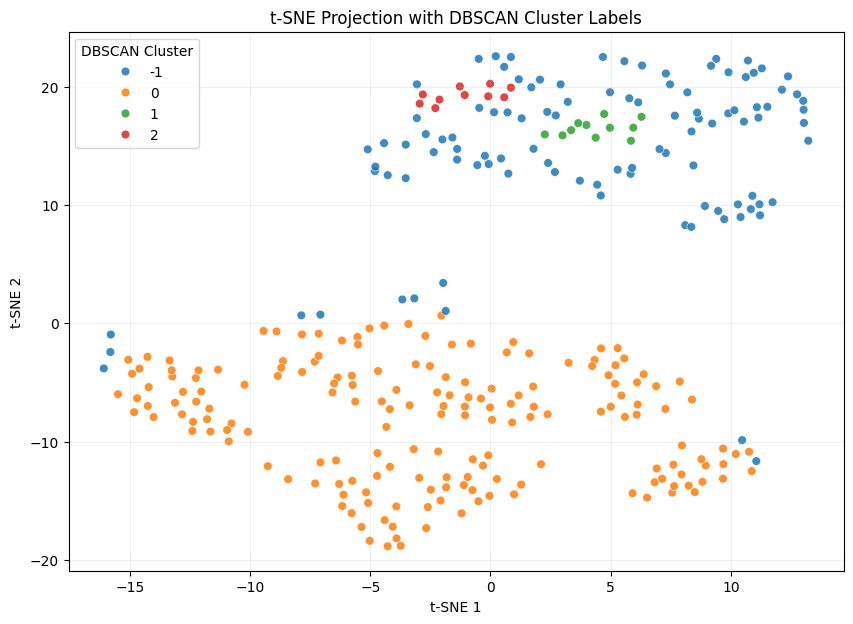

In [147]:
# t-SNE visualization for DBSCAN clusters
from sklearn.manifold import TSNE
import seaborn as sns

tsne_db = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne_db = tsne_db.fit_transform(X_scaled)

df_tsne_db = pd.DataFrame(X_tsne_db, columns=['tsne_1', 'tsne_2'])
df_tsne_db['dbscan_cluster'] = df_small['dbscan_cluster'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_tsne_db,
    x='tsne_1',
    y='tsne_2',
    hue='dbscan_cluster',
    palette='tab10',
    s=40,
    alpha=0.85
)
plt.title('t-SNE Projection with DBSCAN Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(title='DBSCAN Cluster')
plt.grid(True, alpha=0.2)
plt.show()


In [148]:
# --- Model tuning for social media post segmentation ---
# We keep focus on meaningful post behavior groups (low/medium/high engagement patterns).
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

kmeans_candidates = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    kmeans_candidates.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels),
        'inertia': km.inertia_
    })

kmeans_results = pd.DataFrame(kmeans_candidates).sort_values(
    by=['silhouette', 'calinski_harabasz'], ascending=[False, False]
)
kmeans_results


,k,silhouette,calinski_harabasz,davies_bouldin,inertia
3,6,0.304918,119.925858,0.967157,493.493226
4,7,0.304594,121.648487,0.972553,429.664581
5,8,0.304438,116.470066,0.966890,395.560166
2,5,0.291735,116.225288,1.065116,582.312581
1,4,0.288900,112.348239,1.134069,701.372255
0,3,0.275623,103.295582,1.213068,884.646180


In [149]:
# Pick best KMeans by silhouette (strong separation for engagement behavior segments)
best_k = int(kmeans_results.iloc[0]['k'])
best_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
df_small['kmeans_cluster_tuned'] = best_kmeans.fit_predict(X_scaled)

print('Best KMeans k:', best_k)
display(df_small['kmeans_cluster_tuned'].value_counts().sort_index())

# Cluster profile on social media KPI rates
display(
    df_small.groupby('kmeans_cluster_tuned')[features]
    .mean()
    .sort_values('engagement_rate', ascending=False)
)


Best KMeans k: 6


kmeans_cluster_tuned
0    67
1    59
2    59
3    13
4    63
5    39
Name: count, dtype: int64

,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
kmeans_cluster_tuned,,,,,
5,0.042333,0.004166,1.157639,0.019166,0.112153
2,0.040055,0.002648,0.026987,0.001768,0.071020
3,0.032765,0.002992,0.235702,0.144788,0.100826
1,0.030625,0.001899,1.629292,0.021108,0.068018
0,0.026948,0.002460,0.086547,0.003434,0.101680
4,0.025394,0.001146,0.078604,0.005192,0.047905


In [150]:
# Tune DBSCAN: balance between meaningful dense groups and not over-marking posts as noise
dbscan_candidates = []
for eps in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    for min_samples in [5, 8, 10, 12, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)

        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = (labels == -1).mean()

        # Require at least 2 real clusters and enough non-noise points for stability
        if n_clusters >= 2 and mask.sum() >= 30:
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        dbscan_candidates.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette_core': sil
        })

dbscan_results = pd.DataFrame(dbscan_candidates)
dbscan_results = dbscan_results.sort_values(
    by=['silhouette_core', 'noise_ratio'],
    ascending=[False, True],
    na_position='last'
)
dbscan_results.head(15)


,eps,min_samples,n_clusters,noise_ratio,silhouette_core
3,0.4,12,3,0.773333,0.507614
9,0.5,15,2,0.686667,0.460631
7,0.5,10,2,0.600000,0.427920
12,0.6,10,2,0.480000,0.353836
6,0.5,8,2,0.533333,0.342501
1,0.4,8,3,0.656667,0.342289
11,0.6,8,2,0.456667,0.332839
18,0.7,12,2,0.456667,0.330697
25,0.9,5,2,0.186667,0.320611
32,1.0,10,2,0.186667,0.317539


In [151]:
# Prefer high silhouette with practical noise ratio (<= 35%) for social media campaign analysis
dbscan_feasible = dbscan_results[dbscan_results['noise_ratio'] <= 0.35].copy()
if dbscan_feasible['silhouette_core'].notna().any():
    best_db_row = dbscan_feasible.sort_values(
        by=['silhouette_core', 'noise_ratio'], ascending=[False, True]
    ).iloc[0]
else:
    best_db_row = dbscan_results.iloc[0]

best_eps = float(best_db_row['eps'])
best_min_samples = int(best_db_row['min_samples'])

best_dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
df_small['dbscan_cluster_tuned'] = best_dbscan.fit_predict(X_scaled)

print('Best DBSCAN eps:', best_eps, '| min_samples:', best_min_samples)
display(df_small['dbscan_cluster_tuned'].value_counts().sort_index())
display(
    df_small[df_small['dbscan_cluster_tuned'] != -1]
    .groupby('dbscan_cluster_tuned')[features]
    .mean()
    .sort_values('engagement_rate', ascending=False)
)


Best DBSCAN eps: 0.9 | min_samples: 5


dbscan_cluster_tuned
-1     56
 0    180
 1     64
Name: count, dtype: int64

,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
dbscan_cluster_tuned,,,,,
0,0.03226,0.002305,0.000000,0.000000,0.077216
1,0.03095,0.002107,1.505168,0.022531,0.072916


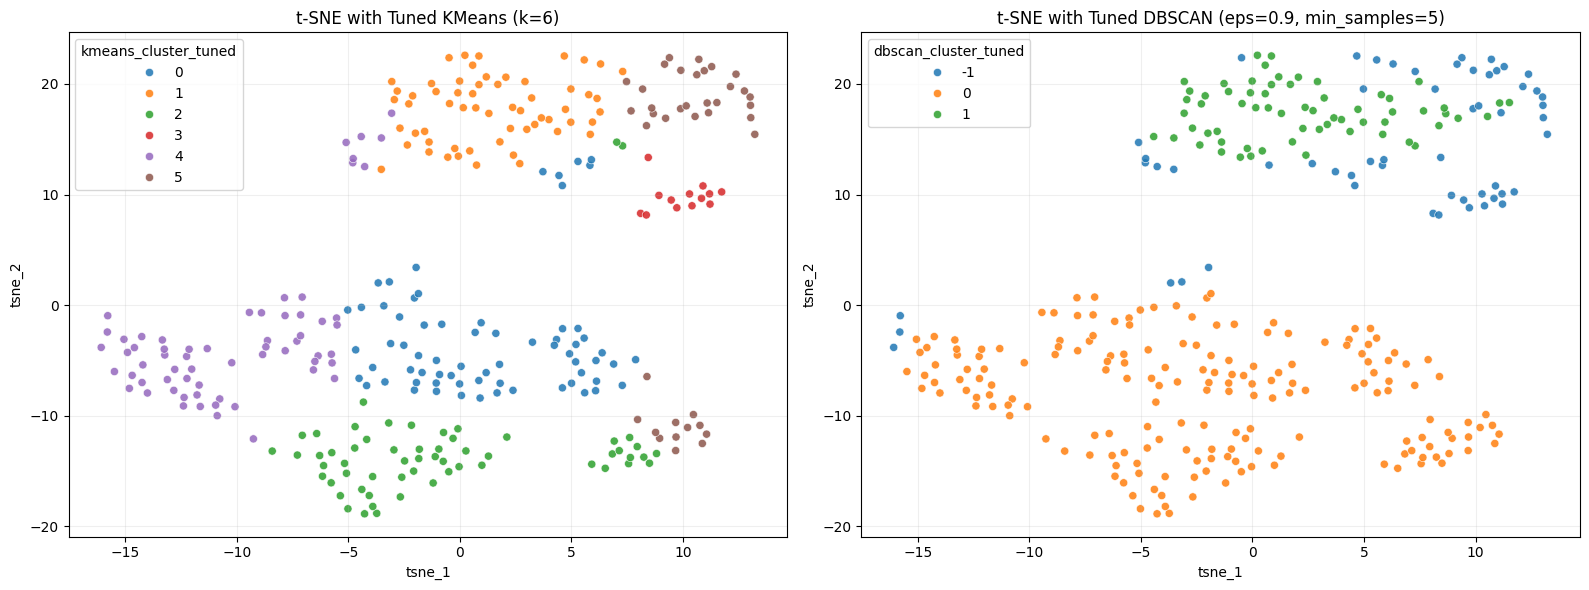

In [152]:
# Final t-SNE visualizations using tuned models
tsne_final = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne_final = tsne_final.fit_transform(X_scaled)
df_tsne_final = pd.DataFrame(X_tsne_final, columns=['tsne_1', 'tsne_2'])
df_tsne_final['kmeans_cluster_tuned'] = df_small['kmeans_cluster_tuned'].values
df_tsne_final['dbscan_cluster_tuned'] = df_small['dbscan_cluster_tuned'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_tsne_final, x='tsne_1', y='tsne_2', hue='kmeans_cluster_tuned', palette='tab10', s=35, alpha=0.85, ax=axes[0])
axes[0].set_title(f't-SNE with Tuned KMeans (k={best_k})')
axes[0].grid(True, alpha=0.2)

sns.scatterplot(data=df_tsne_final, x='tsne_1', y='tsne_2', hue='dbscan_cluster_tuned', palette='tab10', s=35, alpha=0.85, ax=axes[1])
axes[1].set_title(f't-SNE with Tuned DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [153]:
# --- Test: clustering WITHOUT comment_rate ---
features_no_comment = [
    'engagement_rate',
    'view_rate',
    'view_engagement_rate',
    'comments_to_likes_ratio'
]

X_no_comment = df_small[features_no_comment]
scaler_no_comment = StandardScaler()
X_no_comment_scaled = scaler_no_comment.fit_transform(X_no_comment)

print('Using features:', features_no_comment)


Using features: ['engagement_rate', 'view_rate', 'view_engagement_rate', 'comments_to_likes_ratio']


In [154]:
# Tune KMeans without comment_rate
km_rows = []
for k in range(3, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_no_comment_scaled)
    km_rows.append({
        'k': k,
        'silhouette': silhouette_score(X_no_comment_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_no_comment_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_no_comment_scaled, labels)
    })

kmeans_no_comment_results = pd.DataFrame(km_rows).sort_values(
    by=['silhouette', 'calinski_harabasz'], ascending=[False, False]
)
display(kmeans_no_comment_results)

best_k_no_comment = int(kmeans_no_comment_results.iloc[0]['k'])
best_kmeans_no_comment = KMeans(n_clusters=best_k_no_comment, random_state=42, n_init=20)
df_small['kmeans_cluster_no_comment'] = best_kmeans_no_comment.fit_predict(X_no_comment_scaled)

print('Best k without comment_rate:', best_k_no_comment)
display(df_small['kmeans_cluster_no_comment'].value_counts().sort_index())


,k,silhouette,calinski_harabasz,davies_bouldin
0,3,0.354430,115.180913,1.100028
4,7,0.328745,126.813376,0.987340
5,8,0.318456,121.764948,1.017720
3,6,0.317168,129.300935,1.040225
2,5,0.304331,126.958713,0.957586
1,4,0.283877,120.148899,1.098537


Best k without comment_rate: 3


kmeans_cluster_no_comment
0     93
1    194
2     13
Name: count, dtype: int64

In [155]:
# Tune DBSCAN without comment_rate
db_rows = []
for eps in [0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    for min_samples in [5, 8, 10, 12, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_no_comment_scaled)

        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_ratio = (labels == -1).mean()

        if n_clusters >= 2 and mask.sum() >= 30 and len(np.unique(labels[mask])) > 1:
            sil = silhouette_score(X_no_comment_scaled[mask], labels[mask])
        else:
            sil = np.nan

        db_rows.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_ratio': noise_ratio,
            'silhouette_core': sil
        })

dbscan_no_comment_results = pd.DataFrame(db_rows).sort_values(
    by=['silhouette_core', 'noise_ratio'], ascending=[False, True], na_position='last'
)
display(dbscan_no_comment_results.head(15))

db_feasible = dbscan_no_comment_results[dbscan_no_comment_results['noise_ratio'] <= 0.35]
if db_feasible['silhouette_core'].notna().any():
    best_db_row_no_comment = db_feasible.sort_values(
        by=['silhouette_core', 'noise_ratio'], ascending=[False, True]
    ).iloc[0]
else:
    best_db_row_no_comment = dbscan_no_comment_results.iloc[0]

best_eps_no_comment = float(best_db_row_no_comment['eps'])
best_min_samples_no_comment = int(best_db_row_no_comment['min_samples'])
best_dbscan_no_comment = DBSCAN(eps=best_eps_no_comment, min_samples=best_min_samples_no_comment)
df_small['dbscan_cluster_no_comment'] = best_dbscan_no_comment.fit_predict(X_no_comment_scaled)

print('Best DBSCAN without comment_rate: eps=', best_eps_no_comment, ', min_samples=', best_min_samples_no_comment, sep='')
display(df_small['dbscan_cluster_no_comment'].value_counts().sort_index())


,eps,min_samples,n_clusters,noise_ratio,silhouette_core
0,0.4,5,2,0.460000,0.476887
4,0.4,15,3,0.706667,0.467128
2,0.4,10,2,0.613333,0.396954
17,0.7,10,2,0.336667,0.394301
16,0.7,8,2,0.293333,0.386809
23,0.8,12,2,0.303333,0.381063
27,0.9,10,2,0.183333,0.380059
26,0.9,8,2,0.163333,0.378798
20,0.8,5,2,0.170000,0.377466
29,0.9,15,2,0.283333,0.374746


Best DBSCAN without comment_rate: eps=0.7, min_samples=10


dbscan_cluster_no_comment
-1    101
 0    174
 1     25
Name: count, dtype: int64

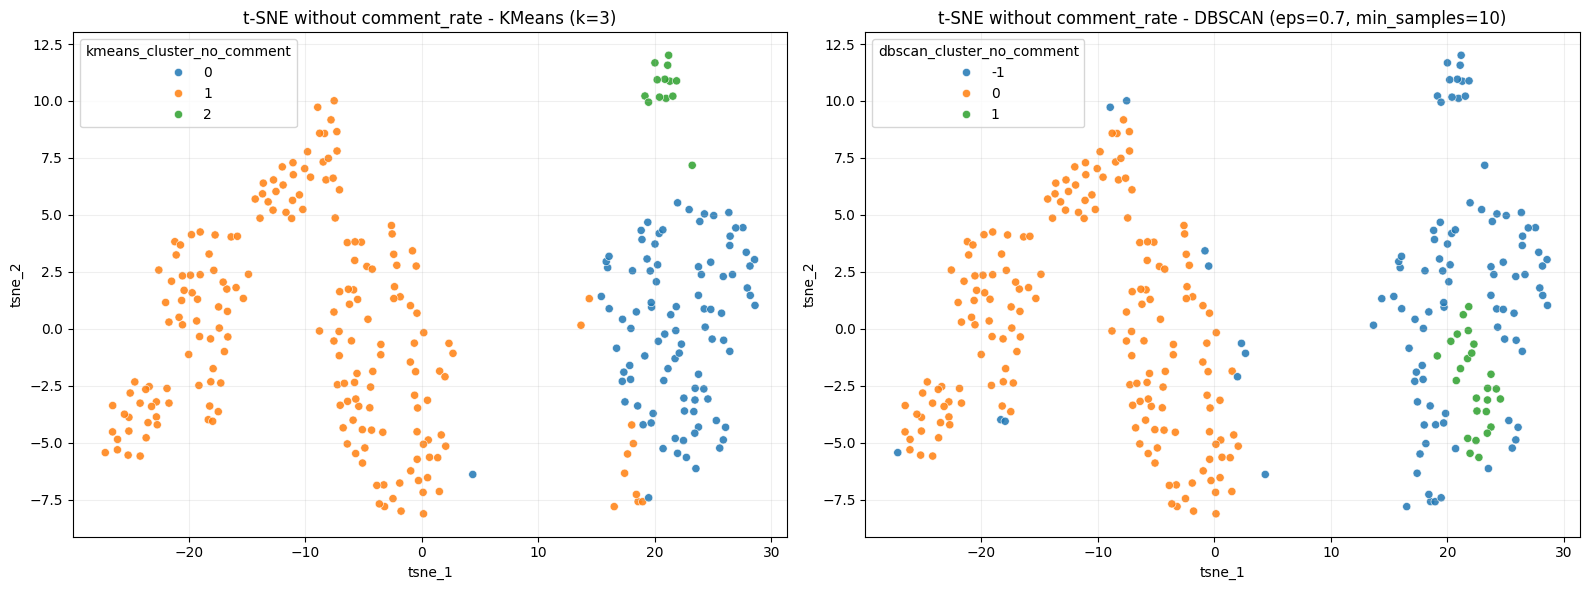

In [156]:
# t-SNE view for no-comment_rate setup
tsne_no_comment = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
X_tsne_no_comment = tsne_no_comment.fit_transform(X_no_comment_scaled)

df_tsne_no_comment = pd.DataFrame(X_tsne_no_comment, columns=['tsne_1', 'tsne_2'])
df_tsne_no_comment['kmeans_cluster_no_comment'] = df_small['kmeans_cluster_no_comment'].values
df_tsne_no_comment['dbscan_cluster_no_comment'] = df_small['dbscan_cluster_no_comment'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_tsne_no_comment, x='tsne_1', y='tsne_2', hue='kmeans_cluster_no_comment', palette='tab10', s=35, alpha=0.85, ax=axes[0])
axes[0].set_title(f't-SNE without comment_rate - KMeans (k={best_k_no_comment})')
axes[0].grid(True, alpha=0.2)

sns.scatterplot(data=df_tsne_no_comment, x='tsne_1', y='tsne_2', hue='dbscan_cluster_no_comment', palette='tab10', s=35, alpha=0.85, ax=axes[1])
axes[1].set_title(f't-SNE without comment_rate - DBSCAN (eps={best_eps_no_comment}, min_samples={best_min_samples_no_comment})')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()


In [157]:
# Show 3 posts from each available cluster label
sample_cols = [
    c for c in [
        'post_id', 'platform', 'post_type', 'caption',
        'followers_count', 'likes_count', 'comments_count', 'views_count',
        'engagement_rate', 'comment_rate', 'view_rate', 'view_engagement_rate', 'comments_to_likes_ratio'
    ] if c in df_small.columns or c in df.columns
]

# Build a display frame from original df + engineered fields + cluster columns
base = df.copy()
for col in ['engagement_rate', 'comment_rate', 'view_rate', 'view_engagement_rate', 'comments_to_likes_ratio']:
    if col in df_small.columns:
        base[col] = df_small[col].values

cluster_cols = [
    c for c in [
        'kmeans_cluster_tuned', 'dbscan_cluster_tuned',
        'kmeans_cluster_no_comment', 'dbscan_cluster_no_comment',
        'cluster', 'dbscan_cluster'
    ] if c in df_small.columns
]

if not cluster_cols:
    print('No cluster label column found. Run clustering cells first.')
else:
    for cc in cluster_cols:
        base[cc] = df_small[cc].values
        print(f'\n===== 3 posts per {cc} =====')
        out = (
            base.groupby(cc, group_keys=False)
            .apply(lambda g: g.head(3))
            .reset_index(drop=True)
        )
        display(out[[cc] + [c for c in sample_cols if c in out.columns]])



===== 3 posts per kmeans_cluster_tuned =====


C:\Users\hanib\AppData\Local\Temp\ipykernel_33832\3790015067.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(3))


,kmeans_cluster_tuned,post_type,followers_count,likes_count,comments_count,views_count,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,0,image,14649,406,31,0.0,0.029831,0.002116,0.000000,0.000000,0.076355
1,0,image,2735,53,5,0.0,0.021207,0.001828,0.000000,0.000000,0.094340
2,0,image,1807,53,5,0.0,0.032097,0.002767,0.000000,0.000000,0.094340
3,1,video,18359,573,48,23365.0,0.033825,0.002615,1.272673,0.026578,0.083770
4,1,reel,10435,386,24,16147.0,0.039291,0.002300,1.547389,0.025392,0.062176
5,1,reel,3287,81,7,5391.0,0.026772,0.002130,1.640097,0.016324,0.086420
6,2,video,8072,307,24,6080.0,0.041006,0.002973,0.753221,0.054441,0.078176
7,2,carousel,4324,178,14,0.0,0.044403,0.003238,0.000000,0.000000,0.078652
8,2,carousel,3179,109,8,0.0,0.036804,0.002517,0.000000,0.000000,0.073394
9,3,reel,4379,134,16,876.0,0.034254,0.003654,0.200046,0.171233,0.119403



===== 3 posts per dbscan_cluster_tuned =====


C:\Users\hanib\AppData\Local\Temp\ipykernel_33832\3790015067.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(3))


...

C:\Users\hanib\AppData\Local\Temp\ipykernel_33832\3790015067.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(3))


,cluster,post_type,followers_count,likes_count,comments_count,views_count,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,0,image,14649,406,31,0.0,0.029831,0.002116,0.000000,0.000000,0.076355
1,0,image,2735,53,5,0.0,0.021207,0.001828,0.000000,0.000000,0.094340
2,0,image,1807,53,5,0.0,0.032097,0.002767,0.000000,0.000000,0.094340
3,1,reel,1688,68,7,1577.0,0.044431,0.004147,0.934242,0.047559,0.102941
4,1,video,8072,307,24,6080.0,0.041006,0.002973,0.753221,0.054441,0.078176
5,1,reel,2669,95,12,4864.0,0.040090,0.004496,1.822405,0.021998,0.126316
6,2,image,6223,217,24,0.0,0.038727,0.003857,0.000000,0.000000,0.110599
7,2,carousel,4324,178,14,0.0,0.044403,0.003238,0.000000,0.000000,0.078652
8,2,carousel,3179,109,8,0.0,0.036804,0.002517,0.000000,0.000000,0.073394
9,3,reel,4379,134,16,876.0,0.034254,0.003654,0.200046,0.171233,0.119403



===== 3 posts per dbscan_cluster =====


C:\Users\hanib\AppData\Local\Temp\ipykernel_33832\3790015067.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.head(3))


,dbscan_cluster,post_type,followers_count,likes_count,comments_count,views_count,engagement_rate,comment_rate,view_rate,view_engagement_rate,comments_to_likes_ratio
0,-1,reel,1688,68,7,1577.0,0.044431,0.004147,0.934242,0.047559,0.102941
1,-1,video,8072,307,24,6080.0,0.041006,0.002973,0.753221,0.054441,0.078176
2,-1,reel,2669,95,12,4864.0,0.040090,0.004496,1.822405,0.021998,0.126316
3,0,image,10435,219,8,0.0,0.021754,0.000767,0.000000,0.000000,0.036530
4,0,image,14649,406,31,0.0,0.029831,0.002116,0.000000,0.000000,0.076355
5,0,image,6223,217,24,0.0,0.038727,0.003857,0.000000,0.000000,0.110599
6,1,video,18359,573,48,23365.0,0.033825,0.002615,1.272673,0.026578,0.083770
7,1,reel,8112,254,19,10188.0,0.033654,0.002342,1.255917,0.026796,0.074803
8,1,reel,10435,325,30,13031.0,0.034020,0.002875,1.248778,0.027243,0.092308
9,2,reel,8112,220,13,14021.0,0.028723,0.001603,1.728427,0.016618,0.059091
